In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
titanic_df = pd.read_csv("../../Downloads/Titanic-Dataset.xls")

In [4]:
uber_df = pd.read_csv("My_Uber_Drives_2016.csv")

In [5]:
## Common arguments for seaborn plots
## - data -> dataframe
## - x --> column name --> in dataframe
## - y --> column name --> in dataframe

## Bivariate Analysis
    ## Scatter plot
    ## Line plot
    ## 2 columns must be numerical columns

## Univariate Analysis
    ## Histogram
    ## Barplot
    ## Boxplot
    ## KDE
    ## Histogram, Boxplot --> Numerical Column
    ## BarPlot --> Categorical Column -->valu_counts() / group by of the categorical column

In [7]:
titanic_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [10]:
titanic_df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [ ]:
## Categorical Columns -- > Survived, Pclass, Sex, Cabin, Embarked, SibSp
## Numerical Columns --> Age, Fare

In [14]:
titanic_df["SibSp"].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [17]:
unique_values_map = dict(map(lambda x:(x,len(titanic_df[x].unique())),titanic_df.columns))

In [16]:
CATEGORICAL_THRESHDOL = 10

In [18]:
categorical_columns = list(filter(lambda x:x[1]<=10, unique_values_map.items()))

In [19]:
categorical_columns

[('Survived', 2),
 ('Pclass', 3),
 ('Sex', 2),
 ('SibSp', 7),
 ('Parch', 7),
 ('Embarked', 4)]

In [20]:
numerical_columns = list(filter(lambda x:x[1]>CATEGORICAL_THRESHDOL, unique_values_map.items()))

In [21]:
numerical_columns

[('PassengerId', 891),
 ('Name', 891),
 ('Age', 89),
 ('Ticket', 681),
 ('Fare', 248),
 ('Cabin', 148)]

In [22]:
## Bivariate Analysis
    ## Scatter plot
    ## Line plot
    ## 2 columns must be numerical columns

## Univariate Analysis
    ## Histogram
    ## Barplot
    ## Boxplot
    ## KDE
    ## Histogram, Boxplot --> Numerical Column
    ## BarPlot --> Categorical Column -->valu_counts() / group by of the categorical column

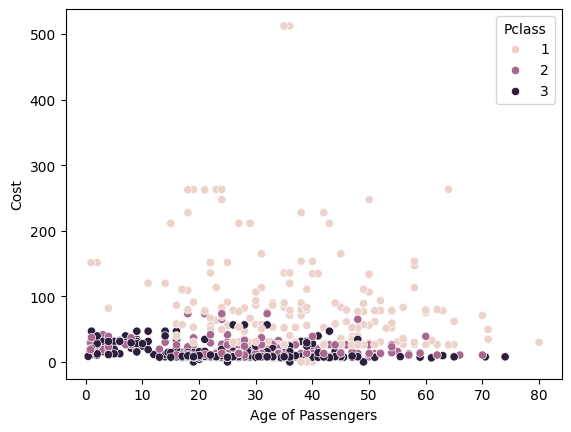

In [28]:
sns.scatterplot(data=titanic_df,x = "Age", y = "Fare", hue="Pclass")
## x numerical, y numerical and hue must be categorical (sensible)
plt.xlabel("Age of Passengers")
plt.ylabel("Cost")
plt.savefig("scatter_plot.png")

<Axes: xlabel='Age', ylabel='Fare'>

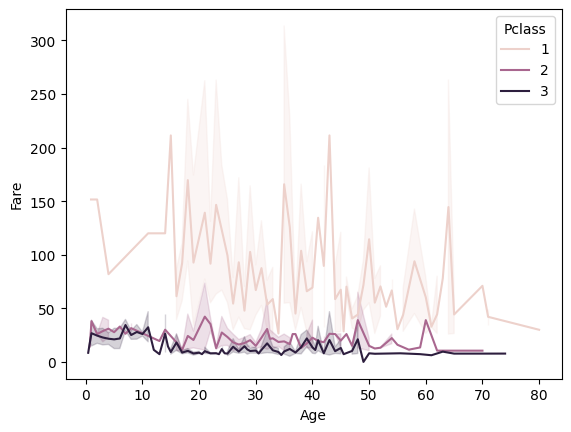

In [31]:
sns.lineplot(data=titanic_df,x="Age",y="Fare",hue="Pclass")

<Axes: xlabel='PURPOSE*'>

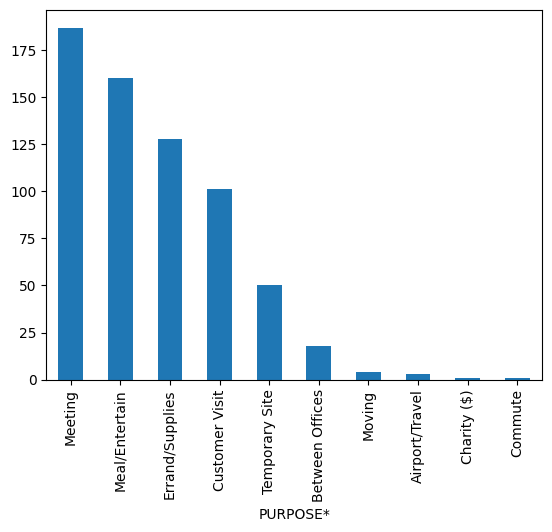

In [35]:
uber_df["PURPOSE*"].value_counts().plot.bar()

<Axes: xlabel='PURPOSE*'>

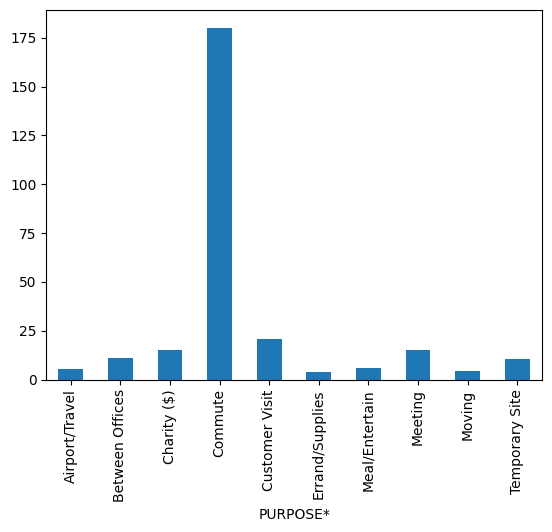

In [37]:
uber_df.groupby("PURPOSE*")["MILES*"].mean().plot.bar()

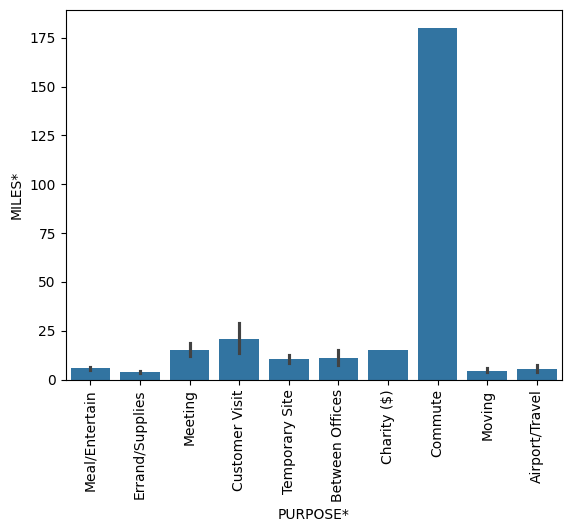

In [40]:
sns.barplot(data=uber_df,x="PURPOSE*",y="MILES*")
plt.xticks(rotation=90);

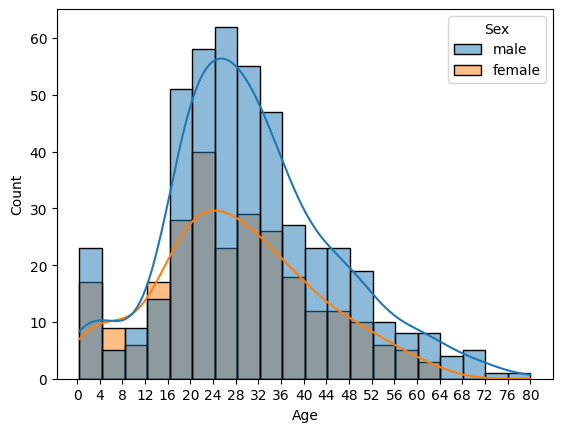

In [59]:
sns.histplot(data=titanic_df,x="Age",bins=20,hue="Sex",kde = "True")
plt.xticks(np.linspace(0,80,21));

In [43]:
min_ = titanic_df["Age"].min()
max_ = titanic_df["Age"].max()
bucket_size = (max_ - min_)/10
buckets = {}
min_1 = min_
for i in range(10):
    buckets[f"bucket-{i+1}"] = {}
    buckets[f"bucket-{i+1}"]["start"] = min_1
    buckets[f"bucket-{i+1}"]["stop"] = min_1 + bucket_size
    buckets[f"bucket-{i+1}"]["count"] = 0
    min_1 += bucket_size

In [44]:
## Binning Algorithm
for age in titanic_df["Age"]:
    for i in range(1,11):
        if (age >= buckets[f"bucket-{i}"]["start"]) and (age < buckets[f"bucket-{i}"]["stop"]):
            buckets[f"bucket-{i}"]["count"] += 1

In [45]:
buckets

{'bucket-1': {'start': 0.42, 'stop': 8.378, 'count': 54},
 'bucket-2': {'start': 8.378, 'stop': 16.336, 'count': 46},
 'bucket-3': {'start': 16.336, 'stop': 24.293999999999997, 'count': 177},
 'bucket-4': {'start': 24.293999999999997,
  'stop': 32.251999999999995,
  'count': 169},
 'bucket-5': {'start': 32.251999999999995,
  'stop': 40.209999999999994,
  'count': 118},
 'bucket-6': {'start': 40.209999999999994,
  'stop': 48.16799999999999,
  'count': 70},
 'bucket-7': {'start': 48.16799999999999,
  'stop': 56.12599999999999,
  'count': 45},
 'bucket-8': {'start': 56.12599999999999,
  'stop': 64.08399999999999,
  'count': 24},
 'bucket-9': {'start': 64.08399999999999,
  'stop': 72.04199999999999,
  'count': 9},
 'bucket-10': {'start': 72.04199999999999,
  'stop': 79.99999999999999,
  'count': 1}}

In [51]:
titanic_df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

<Axes: xlabel='Age', ylabel='Density'>

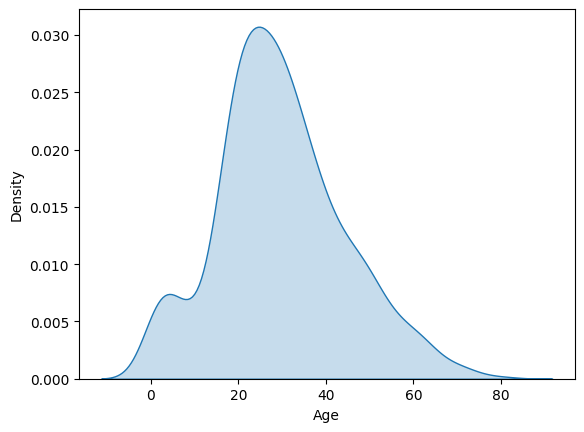

In [63]:
sns.kdeplot(data=titanic_df,x="Age",fill=True)

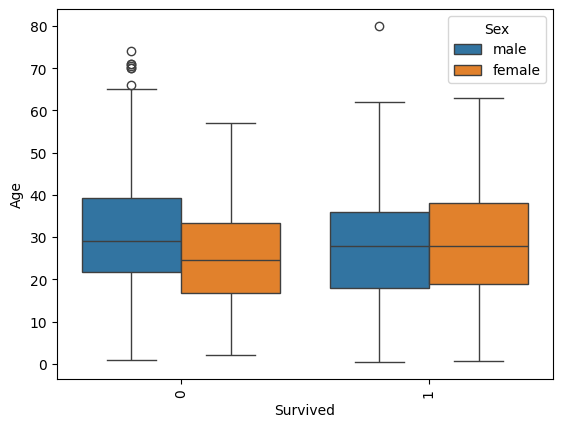

In [69]:
sns.boxplot(data=titanic_df, x = "Survived", y = "Age", hue="Sex")
plt.xticks(rotation=90);
## Statements about this diagram.
## Graphical Statistics
# Descriptive statistics --> 

<Axes: xlabel='Survived', ylabel='Age'>

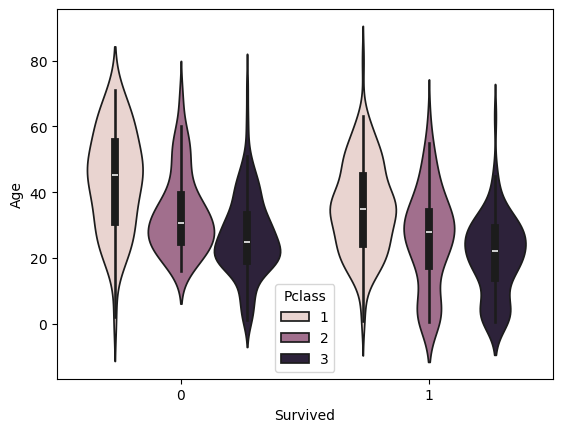

In [71]:
sns.violinplot(data=titanic_df, x= "Survived", y= "Age", hue="Pclass")
## Box plot and as well distriution plot --> KDE

In [72]:
## pairplot
## heatmap

In [74]:
titanic_df.describe() ## Works only for numerical columns

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200
